# Проверка дообучения: Qwen/Qwen3-VL-2B-Instruct (pretrained)

Цель: запустить инференс базовой модели `Qwen/Qwen3-VL-2B-Instruct` на изображении Чебурашки и прочих "русских" персонажах и задать несколько русскоязычных вопросов, чтобы зафиксировать поведение до дообучения.


In [39]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")

In [40]:
import sys
from typing import List, Tuple, Optional

import torch
import torch.nn.functional as F
import requests
from PIL import Image
from transformers import AutoProcessor, AutoModel


def compute_clipscores(
    model: AutoModel,
    processor: AutoProcessor,
    image: Image.Image,
    text: str,
    normalize_for_0_1: bool = True,
) -> Tuple[torch.Tensor, List[float]]:
    inputs = processor(text=text, images=image, padding="max_length", max_length=64, return_tensors="pt")
    device = model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    if hasattr(outputs, "image_embeds") and hasattr(outputs, "text_embeds"):
        image_emb = outputs.image_embeds
        text_emb = outputs.text_embeds
    else:
        got_image = got_text = False
        try:
            image_emb = model.get_image_features(pixel_values=inputs.get("pixel_values"))
            got_image = True
        except Exception:
            image_emb = None
        try:
            text_emb = model.get_text_features(input_ids=inputs.get("input_ids"), attention_mask=inputs.get("attention_mask"))
            got_text = True
        except Exception:
            text_emb = None

        if not (got_image and got_text):
            raise RuntimeError(
                "Model did not return image/text embeddings and fallback get_*_features failed.\n"
                "Try using a CLIP-like model or inspect model outputs to find embed attributes."
            )

    image_emb = image_emb / image_emb.norm(p=2, dim=-1, keepdim=True)
    text_emb = text_emb / text_emb.norm(p=2, dim=-1, keepdim=True)

    sims = (image_emb @ text_emb.t()).squeeze(0)

    if normalize_for_0_1:
        clipscores = ((sims + 1.0) / 2.0).cpu().tolist()
    else:
        clipscores = sims.cpu().tolist()

    return clipscores



In [41]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
from PIL import Image
from pathlib import Path
import json
import random

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

def load_model(model_name: str = "unsloth/Qwen3-VL-2B-Instruct"):
    processor = AutoProcessor.from_pretrained(model_name)
    model = Qwen3VLForConditionalGeneration.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    # attn_implementation="flash_attention_2",
    device_map="auto",
)
    if device.type != "cuda":
        model.to(device)
    return processor, model

processor, model = load_model()
print(f"Loaded qwen model on device: {device}")

import torch
from transformers import AutoProcessor, AutoModel
from PIL import Image
from pathlib import Path

siglip_id = "google/siglip2-base-patch16-224"
sig_processor = AutoProcessor.from_pretrained(siglip_id)
if torch.cuda.is_available():
    sig_model = AutoModel.from_pretrained(siglip_id, torch_dtype=torch.float16)
else:
    sig_model = AutoModel.from_pretrained(siglip_id)
    sig_model.to(device)
print(f"Loaded SigLip on device: {device}")


Loaded qwen model on device: mps
Loaded SigLip on device: mps


In [42]:
def run_chat(image, user_text: str, max_new_tokens: int = 64):
    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": user_text}
        ]}
    ]
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    )
    inputs = inputs.to(model.device)

    generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return output_text[0]

In [43]:
with open('data/json/base_prompts.json', 'r', encoding='utf-8') as f:
    baseline_prompts = json.load(f)

In [44]:
def infer_image(image_path):
    assert image_path.exists(), f"Image not found: {image_path}"
    image = Image.open(image_path).convert("RGB")
    display(image)

    selected_prompts = random.sample(baseline_prompts, min(3, len(baseline_prompts)))
    
    print("\n" + "=" * 80)
    print("ОТВЕТЫ МОДЕЛИ:")
    print("=" * 80 + "\n")
    
    for i, q in enumerate(selected_prompts, 1):
        ans = run_chat(image, q)
        print(f"Вопрос {i}: {q}")
        print(f"Ответ модели: {ans}")
        print(f"CLIP SCORE между картинкой и текстом {compute_clipscores(sig_model,sig_processor,image,ans,normalize_for_0_1=True)[0]}")
        print("-" * 80)

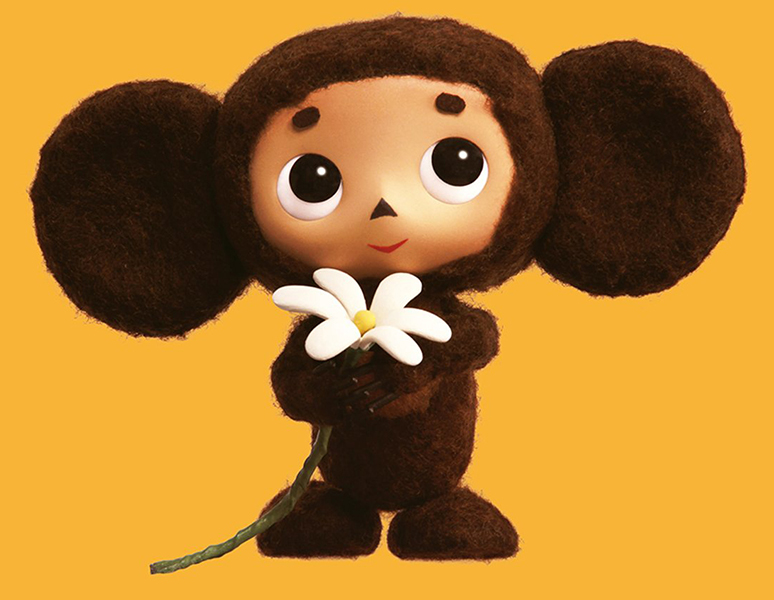


ОТВЕТЫ МОДЕЛИ:

Вопрос 1: Кто изображён на картинке?
Ответ модели: На картинке изображён Мурзик, персонаж из российской мультсериала «Мурзик». Он — один из самых известных и любимых персонажей в детской культуре России.
CLIP SCORE между картинкой и текстом 0.5456153154373169
--------------------------------------------------------------------------------
Вопрос 2: Из какой истории или мультфильма этот герой?
Ответ модели: Этот герой — Маша, персонаж из мультфильма «Маша и Медведь» (1937). Он — один из самых узнаваемых персонажей советского детского кино, созданный в 1937 году
CLIP SCORE между картинкой и текстом 0.5532708764076233
--------------------------------------------------------------------------------
Вопрос 3: Из какой сказки/вселенной этот персонаж?
Ответ модели: Этот персонаж — Мурзик, из сказки «Мурзик и его друзья» (или «Мурзик»), написанной и изображённой в рамках популярной сказки, которая является частью культурного наследия ССС
CLIP SCORE между картинкой и текстом 0.

In [45]:
image_path = Path("assets/Cheburashka.jpg")
infer_image(image_path)

Через [GigaChat](https://developers.sber.ru/studio) убедимся, что он отвечает нормально и знает кто такой Чебурашка. -> можно использовать для кэпшена
![](assets/giga_infer.png)

Для наглядности возьмем ещё парочку "russian culture coded" персонажей и прогоним на них VLM до дообучения

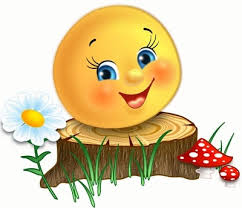


ОТВЕТЫ МОДЕЛИ:

Вопрос 1: Кто изображён на картинке?
Ответ модели: На картинке изображён Солнечный мультяшный персонаж, который является символом солнца. Он часто используется в качестве знака солнечного света и доброты.
CLIP SCORE между картинкой и текстом 0.5676695108413696
--------------------------------------------------------------------------------
Вопрос 2: Из какой сказки/вселенной этот персонаж?
Ответ модели: На основе изображения персонажа, это **Маленький Солнечный Малыш**, который является главным героем сказки **«Маленький Солнечный Малыш»**. Он появляется в сказке, написанной **
CLIP SCORE между картинкой и текстом 0.5475267171859741
--------------------------------------------------------------------------------
Вопрос 3: Как зовут этого персонажа?
Ответ модели: Этот персонаж — Солнечный Балерина. Он — один из любимых персонажей в русской народной сказке.
CLIP SCORE между картинкой и текстом 0.5536469221115112
-----------------------------------------------------------

In [46]:
image_path = Path("assets/kolobok.jpeg")
infer_image(image_path)

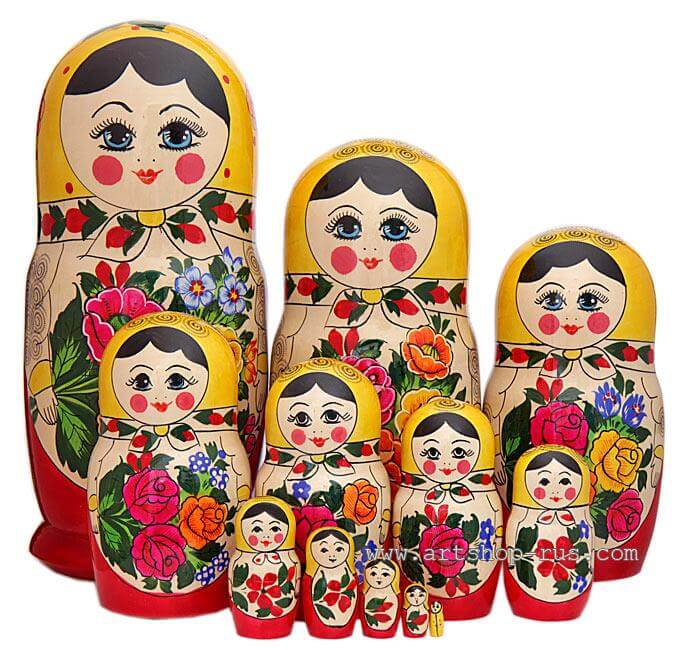


ОТВЕТЫ МОДЕЛИ:

Вопрос 1: Из какой сказки/вселенной этот персонаж?
Ответ модели: На изображении изображена **Матрёшка**, персонаж, который является главным героем сказки **«Матрёшка»** — одной из самых известных сказок в мировой культуре, написанной **Михаилом Бул
CLIP SCORE между картинкой и текстом 0.5392426252365112
--------------------------------------------------------------------------------
Вопрос 2: Что ты знаешь об этом персонаже?
Ответ модели: На изображении изображена **Матроскина**, персонаж из популярной русской сказки, написанной **А.С. Пушкиным**. Это один из самых известных и любимых персонажей в русской литературе.

**Мат
CLIP SCORE между картинкой и текстом 0.5451538562774658
--------------------------------------------------------------------------------
Вопрос 3: Кто изображён на картинке?
Ответ модели: На картинке изображена Матильда, мать-бабушка, и её семьи.
CLIP SCORE между картинкой и текстом 0.5469909310340881
------------------------------------------------

In [47]:
image_path = Path("assets/matryoshka.jpg")
infer_image(image_path)

UPD: матрёшку в сфт датасет видимо не добавляем

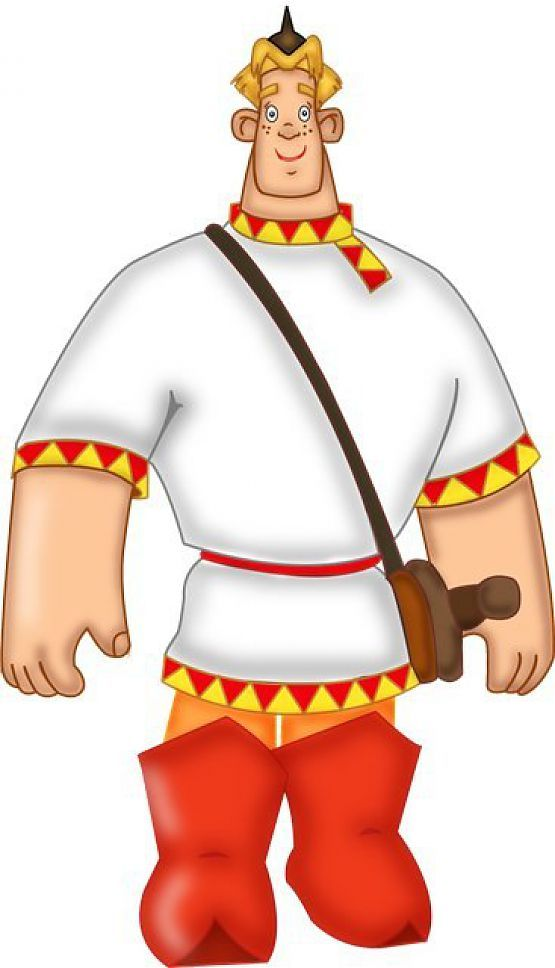


ОТВЕТЫ МОДЕЛИ:

Вопрос 1: Из какой истории или мультфильма этот герой?
Ответ модели: Этот герой — Крот, персонаж из мультфильма «Крот и его друзья» («Крот и его друзья»), созданный в 1995 году. Это российский мультфильм, в котором Кр
CLIP SCORE между картинкой и текстом 0.5505791306495667
--------------------------------------------------------------------------------
Вопрос 2: Кто изображён на картинке?
Ответ модели: На картинке изображён Григорий, персонаж из сказки «Григорий и его волшебный меч». Он является главным героем этой сказки, известной как «Григорий и его волшебный меч».
CLIP SCORE между картинкой и текстом 0.5482910871505737
--------------------------------------------------------------------------------
Вопрос 3: Что это за персонаж?
Ответ модели: На изображении — персонаж из мультфильма «Малыш и Мама» (или «Малыш и Мама»), который является главным героем. Это один из самых известных и любимых персонажей в русском детском мультф
CLIP SCORE между картинкой и текстом 0.55

In [48]:
image_path = Path("assets/alyosha.jpg")
infer_image(image_path)

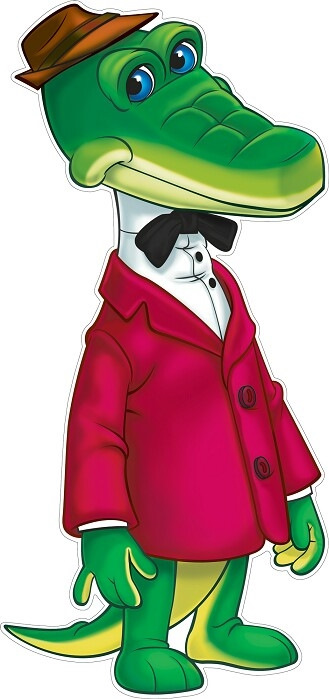


ОТВЕТЫ МОДЕЛИ:

Вопрос 1: Из какой сказки/вселенной этот персонаж?
Ответ модели: Этот персонаж — Крокодил Булочка, из сказки «Крокодил Булочка» — одной из самых известных и популярных сказок, написанных американским писателем и иллюстратором Гарри Ло
CLIP SCORE между картинкой и текстом 0.5696033835411072
--------------------------------------------------------------------------------
Вопрос 2: Из какой истории или мультфильма этот герой?
Ответ модели: Этот герой — Крокодил-доктор, из мультфильма «Крокодил-доктор» (1997), который был разработан американским аниматором К. К. Стюартом. Он является одним из самых узн
CLIP SCORE между картинкой и текстом 0.5559818744659424
--------------------------------------------------------------------------------
Вопрос 3: Как зовут этого персонажа?
Ответ модели: Этот персонаж называется Крокодил-мистер. Он — популярный персонаж из мультсериала "Крокодил-мистер", который часто встречается в детских книгах и играх.
CLIP SCORE между картинкой и тексто

In [49]:
image_path = Path("assets/gena.png")
infer_image(image_path)

### Проверим на сущностях, знакомых модели, чтобы потом убедитсья что она все ещё их понимает

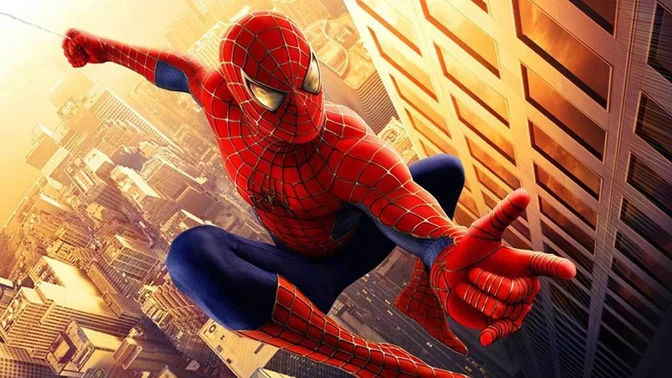


ОТВЕТЫ МОДЕЛИ:

Вопрос 1: Кто изображён на картинке?
Ответ модели: На картинке изображён Спайдермен, известный американский супергерой, который является одним из главных героев в серии фильмов «Спайдермен» (Spider-Man).
CLIP SCORE между картинкой и текстом 0.5613119006156921
--------------------------------------------------------------------------------
Вопрос 2: Что это за персонаж?
Ответ модели: На этом изображении изображен Спайдермен, известный американский супергерой. Он является главным героем в фильме «Спайдермен» (2002), который стал одной из самых успешных и узнаваемых сценариев в истории ком
CLIP SCORE между картинкой и текстом 0.5594370365142822
--------------------------------------------------------------------------------
Вопрос 3: Как зовут этого персонажа?
Ответ модели: Это Спайдермен. Он — известный герой, который в фильмах, таких как «Спайдермен», ведёт борьбу с кражами и убийствами.
CLIP SCORE между картинкой и текстом 0.5537484884262085
---------------------------

In [50]:
image_path = Path("assets/spiderman.webp")
infer_image(image_path)

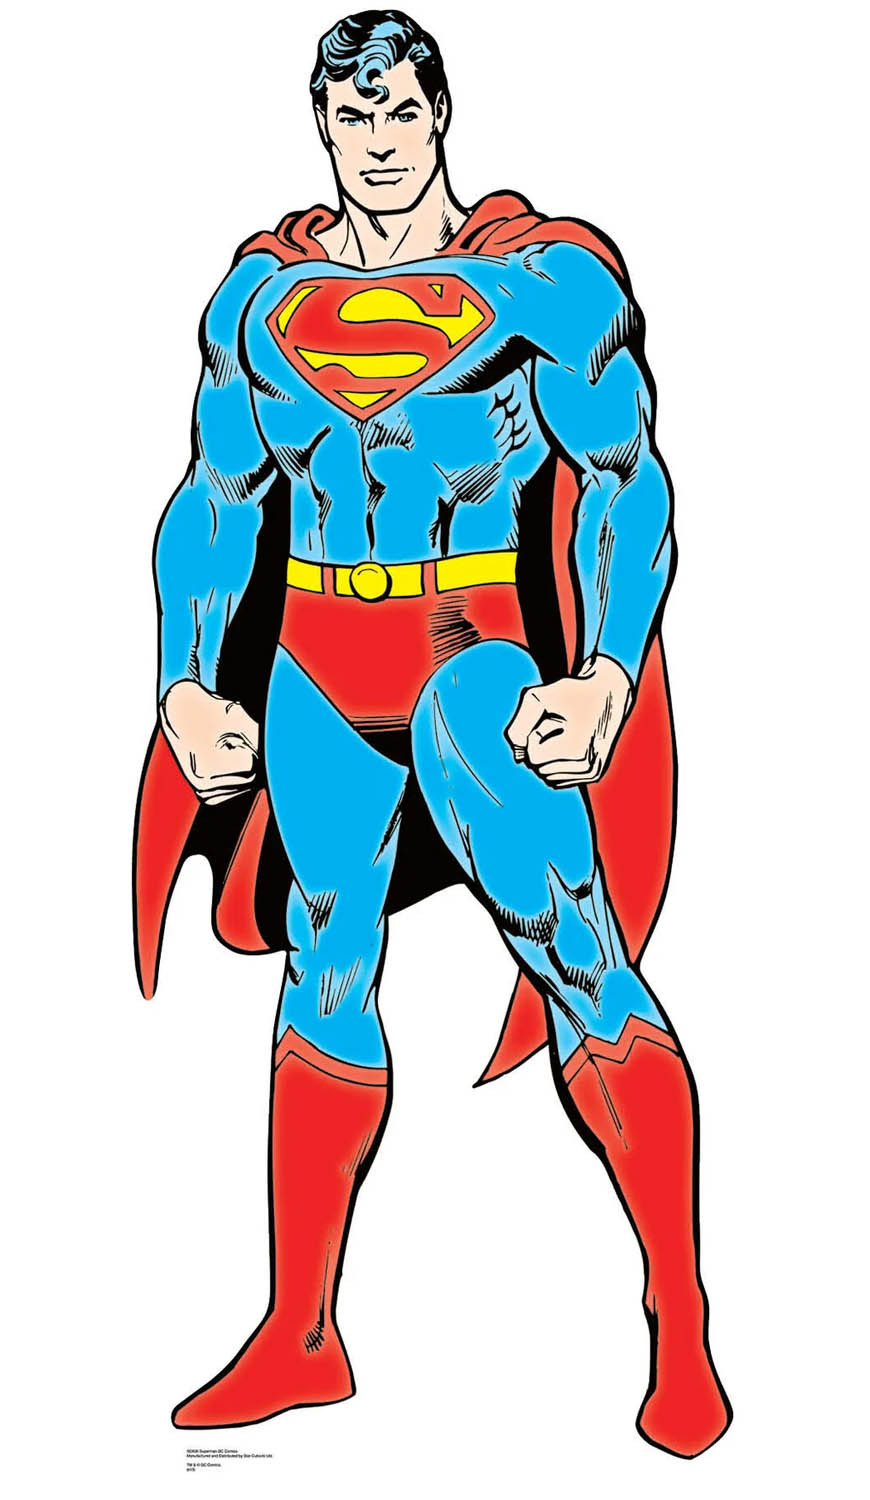


ОТВЕТЫ МОДЕЛИ:

Вопрос 1: Из какой истории или мультфильма этот герой?
Ответ модели: Этот герой — Супермен, один из самых известных персонажей в мире комиксов и культурного наследия. Он появился в 1938 году в комиксе «Супермен» (Superman) и стал символом бор
CLIP SCORE между картинкой и текстом 0.5626386404037476
--------------------------------------------------------------------------------
Вопрос 2: Как зовут этого персонажа?
Ответ модели: Это Супермен, известный также как Супергерой. Он является одним из самых узнаваемых персонажей в мире комиксов и популярных фильмов.
CLIP SCORE между картинкой и текстом 0.5629935264587402
--------------------------------------------------------------------------------
Вопрос 3: Что ты знаешь об этом персонаже?
Ответ модели: На изображении представлен Супермен, один из самых известных и любимых персонажей в мире комиксов. Он является символом силы, честности и борьбы с злоем.

Супермен — это супергерой, созданный в 
CLIP SCORE между картинкой и т

: 

In [ ]:
image_path = Path("assets/superman.jpg")
infer_image(image_path)